In [158]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json

from chars import greek, phys # a list of useful unicode chars
# from fano_factor_viz import filling

In [180]:
cwd = Path(os.getcwd())
results_dir = cwd / "WS2_Grating_Eamonn" / "Results"
results_dir.mkdir(exist_ok=True)

project_folder = results_dir / 'ASYM WS₂, SiO₂, Si [10.5] min_detail=50nm'
json_path = project_folder / 'summary_alpha.json'

with open(json_path, 'r') as file:
    data = json.load(file)
    
data_df = pd.DataFrame(data)
print(data_df.head())
data_df.info()

e_min = 1.2
e_max = 2.2

                                                   0.3000  \
0.0100  {'0.8000': {'0.0100': [1.0, 0.973373915051137,...   
0.0200  {'0.8000': {'0.0100': [0.9727041074360704, 0.9...   
0.0300  {'0.8000': {'0.0100': [1.0, 0.9917011684759475...   
0.0400  {'0.8000': {'0.0100': [0.9916003878164532, 1.0...   
0.0500  {'0.8000': {'0.0100': [0.9097938048948415, 0.9...   

                                                   0.3500  \
0.0100  {'0.8000': {'0.0100': [1.0, 0.9918402365199164...   
0.0200  {'0.8000': {'0.0100': [1.0, 0.9744467070048545...   
0.0300  {'0.8000': {'0.0100': [1.0, 0.9995351737957825...   
0.0400  {'0.8000': {'0.0100': [0.9854607374970955, 0.9...   
0.0500  {'0.8000': {'0.0100': [0.8887730060322535, 0.9...   

                                                   0.4000  
0.0100  {'0.8000': {'0.0100': [1.0, 0.8971617442030987...  
0.0200  {'0.8000': {'0.0100': [1.0, 0.9889368647893044...  
0.0300  {'0.8000': {'0.0100': [0.9946773653290999, 1.0...  
0.0400  {'0.8000': {'0.010

In [181]:
# period, thickness, filling    units micron where appliacable
choose: List[float] = [0.35, 0.02, 0.8]

choose_str = [f"{s:.4f}" for s in choose]
print(choose_str)

alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
print(len(alpha_layer))

x_axis_str = list(alpha_layer.keys())

x_axis = [float(val) for val in x_axis_str]
print(x_axis)
y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T

df_reflectivity = pd.DataFrame(y_data)
df_reflectivity.columns = x_axis
df_reflectivity.index = np.linspace(e_max, e_min, len(df_reflectivity.index))
df_reflectivity.head()


['0.3500', '0.0200', '0.8000']
10
[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]


,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.10
2.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2.191935,0.974447,0.978545,0.983368,0.987516,0.990518,0.992534,0.993894,0.994863,0.995608,0.996218
2.183871,0.936224,0.944160,0.953599,0.961913,0.968161,0.972554,0.975641,0.977896,0.979634,0.981038
2.175806,0.887286,0.898532,0.912131,0.924444,0.934036,0.941044,0.946129,0.949915,0.952843,0.955189
2.167742,0.831492,0.845189,0.862123,0.877945,0.890733,0.900413,0.907640,0.913114,0.917370,0.920767


SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ASYM WS₂, SiO₂, Si [10.5] min_detail=50nm/Energy vs Alpha - 0.35 0.02 0.8.png


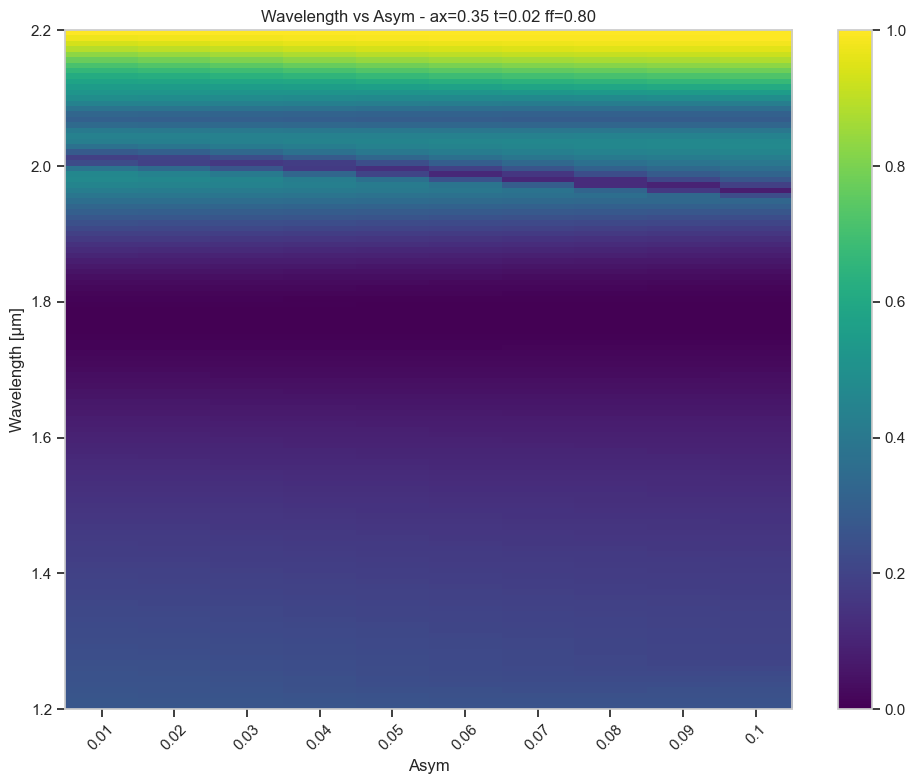

In [182]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing code to prepare the data
df_reflec_wave = df_reflectivity.copy()
# df_reflec_wave.index = 1.24/df_reflectivity.index
df_reflec_wave = df_reflec_wave.sort_index(ascending=False)
df_cropped = df_reflec_wave
df_cropped = df_cropped.loc[:, :]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(df_cropped, cmap='viridis', aspect='auto', extent=[0, df_cropped.shape[1], df_cropped.index.min(), df_cropped.index.max()])

# Generate tick labels with 0.05 increments
# yticklabels = np.round(np.arange(0.55, 1.05, 0.05), 2)
# yticks = np.interp(yticklabels, df_cropped.index, range(len(df_cropped)))

# Set the new tick locations and labels
# ax.set_yticks(yticklabels)
# ax.set_yticklabels(yticklabels)

# Remove gridlines
ax.grid(False)

# Remove extra y scale
ax.set_ylim(df_cropped.index.min(), df_cropped.index.max())

# Add colorbar
plt.colorbar(im)

ax.set_xlabel("Asym")
ax.set_ylabel("Wavelength [μm]")
ax.set_title(f"Wavelength vs Asym - ax={choose[0]:.2f} t={choose[1]:.2f} ff={choose[2]:.2f}")

# plt.xticks(rotation=45)
plt.tight_layout()

choose_str_1 = 'Energy vs Alpha -'
for s in choose:
    choose_str_1 += f' {s}'
choose_str_1 += '.png'

ax.set_xticks(np.arange(len(df_cropped.columns)) + 0.5)
ax.set_xticklabels(df_cropped.columns, rotation=45)


image_path = project_folder / choose_str_1
plt.savefig(image_path, dpi=300)
print(f"SAVED IMAGE TO {image_path}")

plt.tight_layout()
plt.show()


In [162]:
from icecream import ic

alpha_layer = data[choose_str[0]]['0.0100']['0.8000'].keys()
ic(alpha_layer)
ic(data.keys())

ic| alpha_layer: dict_keys(['0.0100', '0.0200', '0.0300', '0.0400', '0.0500', '0.0600', '0.0700', '0.0800', '0.0900', '0.1000'])
ic| data.keys(): dict_keys(['0.3000', '0.3500', '0.4000'])


dict_keys(['0.3000', '0.3500', '0.4000'])

['0.3500', '0.0200', '0.8000']
10
[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ASYM WS₂, SiO₂, Si [10.5] min_detail=50nm/Wavelength vs Alpha - 0.35 0.02 0.8.png


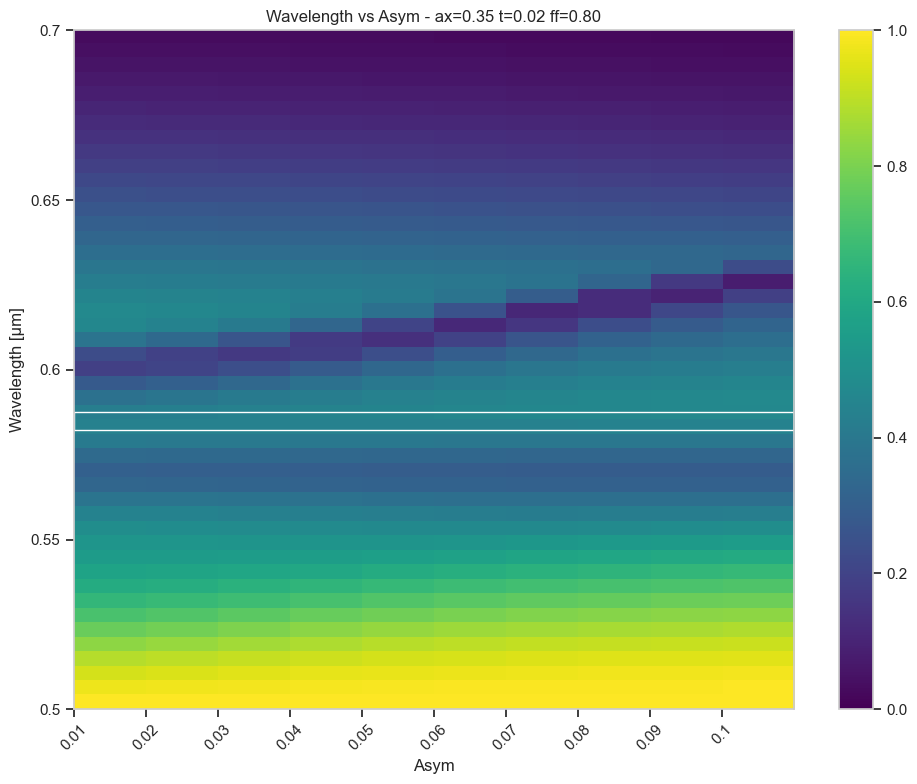

In [163]:
# params = [0.01, 0.02, 0.03, 0.04, 0.05]
params = [0.35]

for p in params:
    # period, thickness, filling    units micron where appliacable
    choose: List[float] = [p, 0.02, 0.8]
    
    choose_str = [f"{s:.4f}" for s in choose]
    print(choose_str)
    
    alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
    print(len(alpha_layer))
    
    x_axis_str = list(alpha_layer.keys())
    
    x_axis = [float(val) for val in x_axis_str]
    print(x_axis)
    
    y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T
    
    df_reflectivity = pd.DataFrame(y_data)
    df_reflectivity.columns = x_axis
    df_reflectivity.index = np.linspace(e_max, e_min, len(df_reflectivity.index))
    df_reflectivity.head()
    
    
    df_reflec_wave = df_reflectivity.copy()
    df_reflec_wave.index = 1.24/df_reflectivity.index
    df_reflec_wave = df_reflec_wave.sort_index(ascending=False)
    df_cropped = df_reflec_wave
    df_cropped = df_cropped.loc[:, :]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(df_cropped, cmap='viridis', aspect='auto', extent=[0, df_cropped.shape[1], df_cropped.index.min(), df_cropped.index.max()])
    
    # Generate tick labels with 0.05 increments
    yticklabels = np.round(np.arange(0.5, 1.1, 0.05), 2)
    yticks = np.interp(yticklabels, df_cropped.index, range(len(df_cropped)))
    
    # Set the new tick locations and labels
    ax.set_yticks(yticklabels)
    ax.set_yticklabels(yticklabels)
    
    
    # Set x-axis ticks and labels
    n_xticks = len(x_axis)
    xticks = np.linspace(0, n_xticks - 1, n_xticks)
    xticklabels = np.round(x_axis, 2)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    
    
    # Remove gridlines
    ax.grid(False)
    
    # Remove extra y scale
    ax.set_ylim(df_cropped.index.min(), df_cropped.index.max())
    
    ax.axhspan(1.24/2.13, 1.24/2.11, fill=0)
    
    # Add colorbar
    plt.colorbar(im)
    
    ax.set_xlabel("Asym")
    ax.set_ylabel("Wavelength [μm]")
    ax.set_title(f"Wavelength vs Asym - ax={choose[0]:.2f} t={choose[1]:.2f} ff={choose[2]:.2f}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    
    choose_str_1 = 'Wavelength vs Alpha -'
    for s in choose:
        choose_str_1 += f' {s}'
    choose_str_1 += '.png'
    
    image_path = project_folder / choose_str_1
    plt.savefig(image_path, dpi=300)
    print(f"SAVED IMAGE TO {image_path}")
    
    plt.ylim([0.5, 0.7])
    plt.show()
    


SAVED IMAGE TO /Users/williamhampshire/Desktop/pycharm/research_project/WS2_Grating_Eamonn/Results/ASYM WS₂, SiO₂, Si [10.5] min_detail=50nm/Wavelength vs Alpha - 0.3 0.04 0.8.png


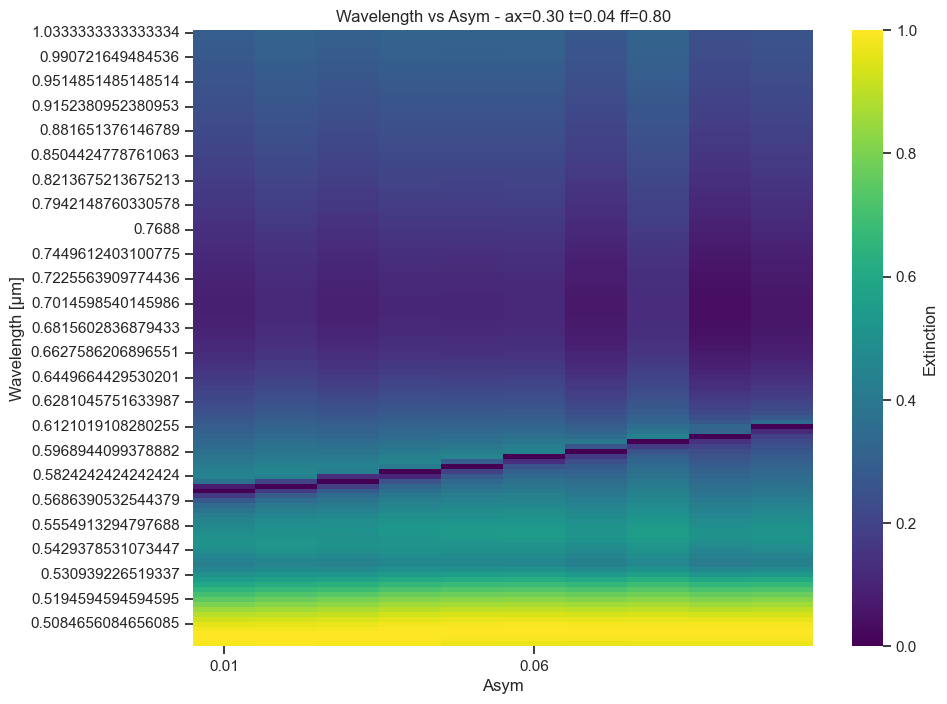

In [165]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
from pathlib import Path

# Assuming `data` is already loaded
params = [0.04]  # Single test case

for p in params:
    # Define structure parameters
    choose: List[float] = [0.3, p, 0.8]
    choose_str = [f"{s:.4f}" for s in choose]
    
    choose_str_1 = 'Wavelength vs Alpha -'
    for s in choose:
        choose_str_1 += f' {s}'
    choose_str_1 += '.png'
    
    # Extract data
    alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
    x_axis_str = list(alpha_layer.keys())
    x_axis = [float(val) for val in x_axis_str]
    
    # Create DataFrame
    y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T
    df_reflectivity = pd.DataFrame(y_data, columns=x_axis)
    
    # Set index as descending energy from 2.2 to 1.2 eV
    df_reflectivity.index = np.linspace(e_max, e_min, len(df_reflectivity.index))
    
    # Convert to Wavelength (λ = 1.24 / E) & sort ascending
    df_reflec_wave = df_reflectivity.copy()
    df_reflec_wave.index = 1.24 / df_reflectivity.index
    df_reflec_wave = df_reflec_wave.sort_index(ascending=False)  # Ensure correct order

    # Plot using Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        df_reflec_wave,
        cmap="viridis",
        xticklabels=5,  # Adjust based on the number of alpha values
        yticklabels=5,  # Adjust for wavelength scale
        cbar_kws={'label': 'Extinction'},
    )
    
    

    # Labels & title
    plt.xlabel("Asym")
    plt.ylabel("Wavelength [μm]")
    plt.title(f"Wavelength vs Asym - ax={choose[0]:.2f} t={choose[1]:.2f} ff={choose[2]:.2f}")

    # Save and show
    image_path = project_folder / choose_str_1
    plt.savefig(image_path, dpi=300)
    print(f"SAVED IMAGE TO {image_path}")

    plt.show()


ic| new_cols: [0, 5]


[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]


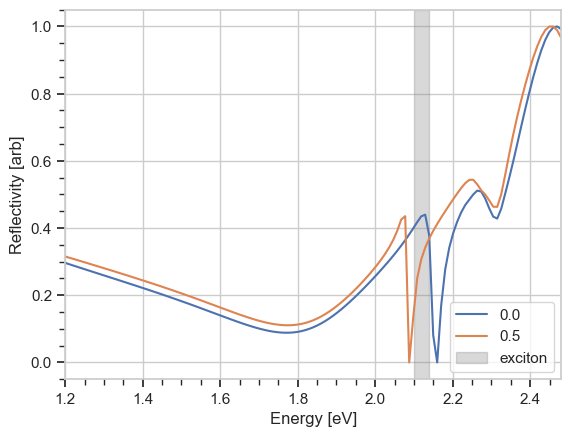

In [166]:
from typing import List
from icecream import ic
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


choose_str = [f"{s:.4f}" for s in choose]
alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
x_axis_str = list(alpha_layer.keys())
x_axis = [float(val) for val in x_axis_str]
print(x_axis)

y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T

df_reflectivity = pd.DataFrame(y_data)
df_reflectivity.index = np.linspace(e_max, e_min, len(df_reflectivity.index))


def get_cols(columns:List[float], interval_ind:float) -> List[float]:
    """
    Use the columns list and index interval to get a new list of columns to plot (coarser steps)
    :param columns: List[float]
    :param interval_ind: float
    :return: List[float]
    """
    index = 0
    new_cols = []
    while index < len(columns):
        new_cols.append(columns[index])
        index += interval_ind
        
    return new_cols


alpha_graph_resolution = 0.1
alpha_plotting_interval = 5 # steps
new_cols = get_cols(df_reflectivity.columns, alpha_plotting_interval)

ic(new_cols)


# plotting
fig, ax = plt.subplots()
sns.set_theme(style="whitegrid")
plt.rcParams.update({"xtick.bottom" : True, "ytick.left" : True})

for col in new_cols:
    sns.lineplot(ax=ax, data=df_reflectivity, x=df_reflectivity.index, y=col, label=str(col*alpha_graph_resolution))



ax.set_xlabel('Energy [eV]')
ax.set_ylabel('Reflectivity [arb]')

ax.minorticks_on()
ax.set_xlim([e_min,e_max])
# ax.set_ylim([0,1])

ax.axvspan(xmin=2.1, xmax=2.14, color='grey', alpha=0.3, label='exciton')


# Add legend and show the plot
ax.legend(loc='lower right')



ic| new_cols: [0, 5]


[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]


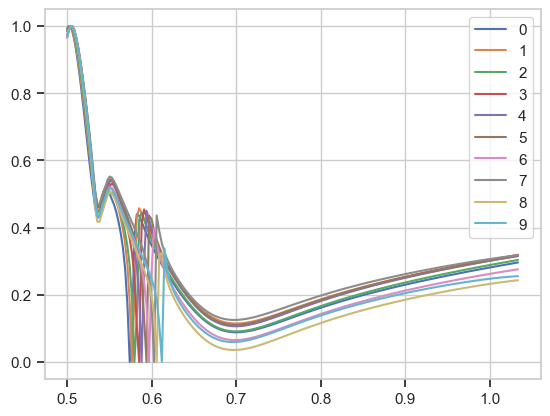

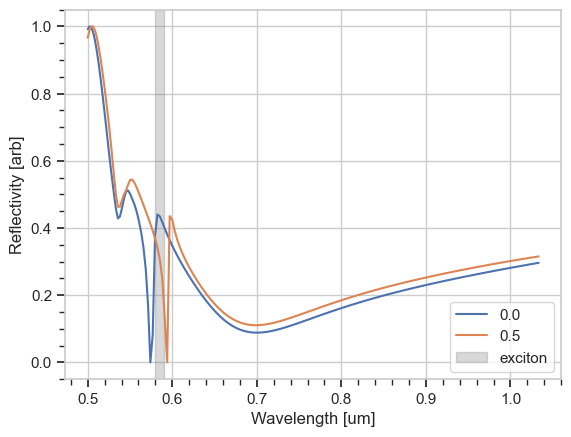

In [167]:
from typing import List
from icecream import ic
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

choose_str = [f"{s:.4f}" for s in choose]
alpha_layer = data[choose_str[0]][choose_str[1]][choose_str[2]]
x_axis_str = list(alpha_layer.keys())
x_axis = [float(val) for val in x_axis_str]
print(x_axis)

y_data = np.array([alpha_layer[f'{x}'] for x in x_axis_str]).T

df_reflectivity = pd.DataFrame(y_data)
df_reflectivity.index = np.linspace(e_max, e_min, len(df_reflectivity.index))
df_reflectivity.index = 1.24/df_reflectivity.index

df_reflectivity.plot()

def get_cols(columns:List[float], interval_ind:float) -> List[float]:
    """
    Use the columns list and index interval to get a new list of columns to plot (coarser steps)
    :param columns: List[float]
    :param interval_ind: float
    :return: List[float]
    """
    index = 0
    new_cols = []
    while index < len(columns):
        new_cols.append(columns[index])
        index += interval_ind
        
    return new_cols


alpha_graph_resolution = 0.1
alpha_plotting_interval = 5 # steps
new_cols = get_cols(df_reflectivity.columns, alpha_plotting_interval)

ic(new_cols)


# plotting
fig, ax = plt.subplots()
sns.set_theme(style="whitegrid")
plt.rcParams.update({"xtick.bottom" : True, "ytick.left" : True})

for col in new_cols:
    sns.lineplot(ax=ax, data=df_reflectivity, x=df_reflectivity.index, y=col, label=str(col*alpha_graph_resolution))



ax.set_xlabel('Wavelength [um]')
ax.set_ylabel('Reflectivity [arb]')

ax.minorticks_on()
# ax.set_xlim([1.2, 2.2])
# ax.set_ylim([0,1])

ax.axvspan(xmin=1.24/2.1, xmax=1.24/2.14, color='grey', alpha=0.3, label='exciton')


# Add legend and show the plot
ax.legend(loc='lower right')



In [145]:
print()